**Predicting Late Deliveries in E-Commerce Using Machine Learning**

This project analyzes delivery performance in an e-commerce dataset to understand the impact of delays on customer satisfaction. Using exploratory data analysis and machine learning models (Logistic Regression and Random Forest), the study identifies key factors influencing late deliveries and compares model performance under class imbalance conditions.

Step 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading datasets
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

# Standardizing column names
for df in [orders, reviews, customers, order_items, products]:
    df.columns = df.columns.str.strip().str.lower()

# Merging orders + reviews + customers
df = orders.merge(reviews[['order_id','review_score']], on='order_id', how='left')
df = df.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')

# Converting date columns
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Delivery metrics
df['actual_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['late_delivery'] = (df['delivery_delay'] > 0).astype(int)  # for ML


This cell imports necessary libraries like pandas for data manipulation, numpy for numerical operations, and matplotlib/seaborn for plotting. It then loads several CSV datasets related to e-commerce orders, reviews, customers, order items, and products. The column names are standardized by converting them to lowercase and removing leading/trailing spaces. Finally, it merges the `orders`, `reviews`, and `customers` dataframes and converts relevant timestamp columns to datetime objects, calculating `actual_delivery_days`, `estimated_delivery_days`, `delivery_delay`, and a binary `late_delivery` flag.

Step 2

In [ ]:
# Percentage of late deliveries
late_percentage = (df['late_delivery'].mean()) * 100
print(f"Late deliveries: {late_percentage:.2f}%")

# Impact on review score
df.groupby('late_delivery')['review_score'].mean()

Late deliveries: 6.56%


,review_score
late_delivery,
0,4.211789
1,2.271139


This cell calculates and prints the percentage of late deliveries in the dataset. It then groups the DataFrame by the `late_delivery` status (0 for on-time, 1 for late) and computes the average `review_score` for each group, showing the impact of late deliveries on customer satisfaction.

Step 3

In [ ]:
# Aggregate by state
state_summary = df.groupby('customer_state').agg(
    avg_delay=('delivery_delay','mean'),
    late_percentage=('late_delivery','mean'),
    avg_review=('review_score','mean')
).sort_values(by='avg_delay', ascending=False)

# Top 3 worst states
top3_states = state_summary.head(3).index.tolist()
state_summary['highlight'] = state_summary.index.isin(top3_states)

This cell aggregates delivery performance metrics by `customer_state`. It calculates the average delivery delay, the percentage of late deliveries, and the average review score for each state. The results are sorted by `avg_delay` in descending order. It then identifies the top 3 states with the worst average delay and adds a 'highlight' column to flag these states.

Step 4

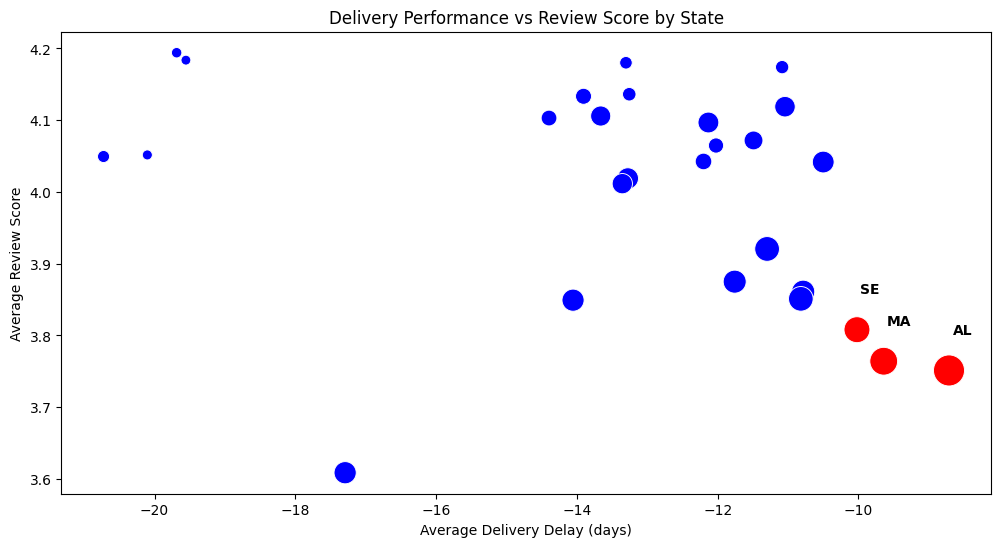

In [ ]:
# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=state_summary,
    x='avg_delay',
    y='avg_review',
    size='late_percentage',
    hue='highlight',
    palette={True:'red', False:'blue'},
    sizes=(50,500),
    legend=False
)
for i in state_summary.index:
    if state_summary.loc[i,'highlight']:
        plt.text(
            state_summary.loc[i,'avg_delay']+0.05,
            state_summary.loc[i,'avg_review']+0.05,
            s=i, fontweight='bold'
        )
plt.title('Delivery Performance vs Review Score by State')
plt.xlabel('Average Delivery Delay (days)')
plt.ylabel('Average Review Score')
plt.show()

This cell generates a scatter plot to visualize the relationship between average delivery delay and average review score per state. The size of the points represents the `late_percentage`, and the top 3 states with the highest delays are highlighted in red for easy identification. Text labels are added to the highlighted states.

Step 5

In [ ]:
# Compute order value
order_value = order_items.groupby('order_id')['price'].sum().reset_index()
df = df.merge(order_value, on='order_id', how='left')

# Merge product category (optional)
df = df.merge(order_items[['order_id','product_id']], on='order_id', how='left')
df = df.merge(products[['product_id','product_category_name']], on='product_id', how='left')

# Select features for ML
ml_df = df[['late_delivery','estimated_delivery_days','customer_state','price','product_category_name']].dropna()

# Encode categorical features
ml_df = pd.get_dummies(ml_df, columns=['customer_state','product_category_name'], drop_first=True)

This cell prepares the data for machine learning. It first calculates the total `price` for each order by summing the prices of individual items and merges this with the main DataFrame. It then merges product category information. Finally, it selects relevant features (`late_delivery`, `estimated_delivery_days`, `customer_state`, `price`, `product_category_name`), drops rows with missing values, and one-hot encodes the categorical features (`customer_state` and `product_category_name`) for use in machine learning models.

Step 6

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split
X = ml_df.drop('late_delivery', axis=1)
y = ml_df['late_delivery']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

Accuracy: 0.9233248287901168
[[20327   620]
 [ 1093   301]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     20947
           1       0.33      0.22      0.26      1394

    accuracy                           0.92     22341
   macro avg       0.64      0.59      0.61     22341
weighted avg       0.91      0.92      0.92     22341



,0
price,0.467968
estimated_delivery_days,0.262420
customer_state_SP,0.021659
customer_state_RJ,0.016761
product_category_name_esporte_lazer,0.008377
product_category_name_moveis_decoracao,0.008350
product_category_name_informatica_acessorios,0.008318
product_category_name_beleza_saude,0.007229
customer_state_MG,0.007170
product_category_name_cama_mesa_banho,0.007165


This cell trains and evaluates a Random Forest Classifier. It splits the data into training and testing sets. A Random Forest model is initialized with `n_estimators=100` and `class_weight='balanced'` to handle class imbalance, then trained on the training data. The model's predictions are made on the test set, and its performance is evaluated using accuracy, confusion matrix, and a classification report. Finally, it prints the top 10 most important features identified by the Random Forest model.

Step 7

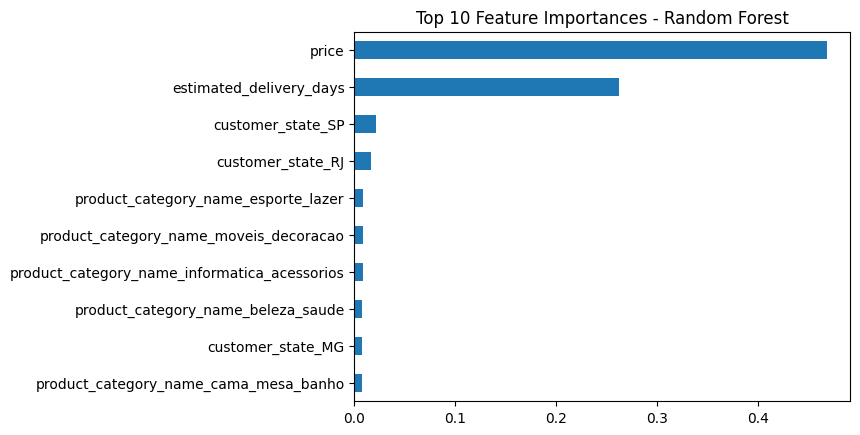

In [ ]:
importances.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()

This cell visualizes the top 10 feature importances from the Random Forest model using a horizontal bar plot, with the y-axis inverted to display the most important features at the top.

Step 8

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.67      0.79     20947
           1       0.11      0.60      0.18      1394

    accuracy                           0.66     22341
   macro avg       0.53      0.64      0.48     22341
weighted avg       0.91      0.66      0.75     22341



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This cell trains and evaluates a Logistic Regression model. Similar to the Random Forest, it initializes a Logistic Regression model with `class_weight='balanced'` and trains it on the `X_train` and `y_train` data. It then makes predictions on the `X_test` data and prints a classification report to evaluate the model's performance.

Step 9

In [ ]:
from sklearn.metrics import roc_auc_score

print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("LR AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))

RF AUC: 0.6974457260754905
LR AUC: 0.6773504476933963


This cell calculates and prints the ROC-AUC score for both the Random Forest and Logistic Regression models, providing another metric to compare their performance, especially valuable in imbalanced datasets.

Step 10

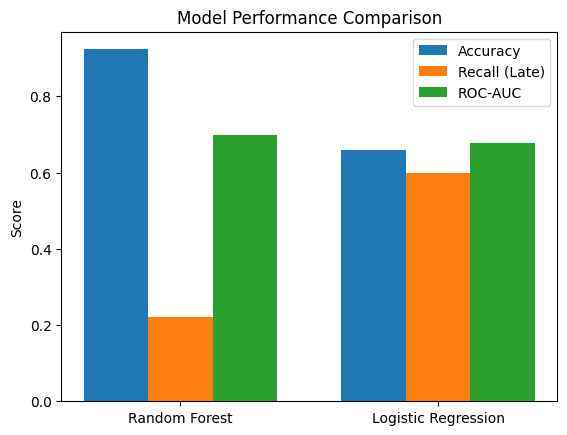

In [ ]:
import matplotlib.pyplot as plt

# Model metrics
models = ['Random Forest', 'Logistic Regression']

accuracy = [0.9233, 0.66]
recall_late = [0.22, 0.60]
roc_auc = [0.6974, 0.6773]

# Create grouped bar positions
x = np.arange(len(models))
width = 0.25

# Plot
plt.figure()
plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, recall_late, width, label='Recall (Late)')
plt.bar(x + width, roc_auc, width, label='ROC-AUC')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

This cell visualizes the performance comparison between the Random Forest and Logistic Regression models. It creates a grouped bar chart showing the accuracy, recall for late deliveries, and ROC-AUC for both models, making it easy to compare their effectiveness across different metrics.

**Project Summary**

This project aimed to analyze delivery performance in an e-commerce dataset, focusing on the impact of delays on customer satisfaction and predicting late deliveries. Key steps included:

Data Loading and Preprocessing: Multiple e-commerce datasets (orders, reviews, customers, order items, products) were loaded, standardized, and merged into a single DataFrame. Date columns were converted, and delivery metrics like actual_delivery_days, estimated_delivery_days, delivery_delay, and late_delivery were engineered.

Exploratory Data Analysis (EDA):
It was found that 6.56% of deliveries were late.
Late deliveries had a significant negative impact on customer satisfaction, with an average review score of 2.27 for late deliveries compared to 4.21 for on-time deliveries.
Analysis by customer state identified AL, MA, and SE as the top 3 states with the highest average delivery delays, which also correlated with lower review scores.

Machine Learning Model Development: The goal was to predict late_delivery using features like estimated_delivery_days, price, customer_state, and product_category_name.
The dataset exhibited class imbalance, with a majority of on-time deliveries.
Random Forest Classifier and Logistic Regression models were trained with class_weight='balanced' to mitigate the imbalance.
Random Forest achieved an accuracy of approximately 0.92, a recall for late deliveries of 0.22, and an ROC-AUC of 0.697. Feature importance revealed price and estimated_delivery_days as the most influential factors.
Logistic Regression achieved an accuracy of approximately 0.66, a recall for late deliveries of 0.60, and an ROC-AUC of 0.677.
A visual comparison of model performance highlighted the trade-offs between accuracy and recall for the minority class across models.


**Suggestions for Future Work:**

Enhanced Class Imbalance Handling:

While class_weight='balanced' was used, the recall for late deliveries (the minority class) is still relatively low, especially for Random Forest. Consider exploring:
Oversampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) or ADASYN.
Undersampling techniques (e.g., RandomUnderSampler), though care must be taken not to lose valuable information.
Cost-sensitive learning where misclassifying a late delivery is penalized more heavily.

Model Optimization:

Further improve model performance and generalization:
Hyperparameter Tuning: Implement GridSearchCV or RandomizedSearchCV for both Random Forest and Logistic Regression to find optimal parameters.

Cross-Validation:

Use k-fold cross-validation during training to get a more robust estimate of model performance.

Experiment with Advanced Models:

Explore Gradient Boosting Machines (e.g., XGBoost, LightGBM, CatBoost) which often perform very well on tabular data and can handle class imbalance.

Advanced Feature Engineering: Develop more sophisticated features:

Time-based Features: Extract day of the week, month, season, or even time of day from order_purchase_timestamp to capture seasonality or daily patterns.

Interaction Features:

Create interactions between existing features (e.g., price * estimated_delivery_days).

Geospatial Features:

If seller location data is available, calculate the distance between customer and seller, as this could be a strong predictor of delivery time.

Seller Performance Metrics:

Incorporate features related to seller's historical delivery performance or average review scores.

Deeper Causal Analysis:

Investigate the reasons behind delays. This might involve looking into external factors (e.g., weather data, holidays) or internal logistics (e.g., warehouse capacity, shipping carrier issues).

Alternative Evaluation Metrics:

Beyond accuracy, focus on metrics most relevant to the business problem, such as F1-score, Precision-Recall Curve, and Average Precision for the minority class, which are more informative in imbalanced datasets.

Interpretability:

For deployment, understanding why a delivery is predicted to be late is crucial. Tools like SHAP or LIME can help explain individual predictions, especially for more complex models.

Deployment and Monitoring:

Discuss how this model could be integrated into an operational system to proactively identify potential late deliveries and trigger interventions (e.g., early communication with customers, alternative shipping arrangements).